# CFRM 521/421 Machine Learning for Finance
## Group 12

**Project Title: Credit Default Prediction** 

**Group Members:**  
- Kayleen Tauhid (email: tauhid@uw.edu, Algorithm: Logistic Regression)  
- Kevin Ryu (email: fbtmdgh@uw.edu, Algorithm: Random Forest)  
- Carlos Pineda (email: cpined@uw.edu, Algorithm: Support Vector Machine)  
- Charlie Price (email: cprice5@uw.edu, Algorithm: Gradient Boosting)  

**Date: 06/07/2026** 


# Introduction

## Problem Statement
- The goal of this project is to predict whether a borrower will default on a loan using machine learning classification models. Credit default prediction is an important problem in finance because financial institutions use these models to evaluate lending risk and reduce potential losses.

## Related Literature
- Predicting credit defaults has shifted from traditional statistical models to advanced machine learning algorithms, which are better prepared to capture complex consumer behaviors (Khandani et al., 2010). Studies show that ensemble methods like Random Forest and Gradient Boosting, along with Support Vector Machines, consistently outperform baseline models in credit scoring accuracy (Lessmann et al., 2015). Our project builds on the foundation set by these papers by utilizing the Default of Credit Card Clients dataset. By comparing a traditional Logistic Regression baseline against these advanced classifiers, we aim to empirically validate the performance gains of modern machine learning techniques on this specific financial dataset.

- References:
- Khandani, A. E., Kim, A. J., & Lo, A. W. (2010). Consumer credit-risk models via machine-learning algorithms. Journal of Banking & Finance, 34(11), 2767-2787. http://dx.doi.org/10.1016/j.jbankfin.2010.06.001
- Lessmann, S., Baesens, B., Seow, H. V., & Thomas, L. C. (2015). Benchmarking state-of-the-art classification algorithms for credit scoring. European Journal of Operational Research, 247(1), 124-136. http://dx.doi.org/10.1016/j.ejor.2015.05.030
- Yeh, I. C., & Lien, C. H. (2009). The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients. Expert Systems with Applications, 36(2), 2473-2480. http://dx.doi.org/10.1016/j.eswa.2007.12.020


## Contribution
- The main contribution of this project is an empirical comparison of multiple machine learning methods for credit default prediction using the Default of Credit Card Clients dataset. Rather than proposing a new algorithm, we focus on how different modeling approaches perform on the same financial dataset.


# Data Description

## Data Source
- Explanation: The Default of Credit Card Clients dataset contains financial and demographic information for 30,000 credit card customers in Taiwan, and our group will use it to predict whether a customer will default on their payment the following month. We plan to compare several machine learning models, such as Logistic Regression, Random Forest, Support Vector Machine, and Gradient Boosting..
- Link: https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset 

## Data Structure
- Each row in the dataset represents an individual credit card client in Taiwan. The dataset contains demographic information, credit-related information, billing statements, payment histories, and the customer's default status.
- The data are cross-sectional rather than time-series data, meaning that each observation corresponds to a different customer rather than repeated measurements over time. Therefore, there is no specific sampling frequency such as daily, monthly, or quarterly observations.
- The dataset consists of 30,000 observations and includes information on customer characteristics such as credit limit, age, education level, marital status, monthly bill amounts, and previous payment records. The target variable, default.payment.next.month, indicates whether a customer defaulted on their credit card payment in the following month.
- The dataset was collected from a Taiwanese credit card issuer. The explanatory variables include billing and payment information from April 2005 through September 2005, while the target variable records whether the customer defaulted on payment in October 2005.

## Target Variable
- The target variable in this project is default.payment.next.month, a binary classification variable that indicates whether a customer defaulted on their credit card payment in the following month. A value of 1 represents a customer who defaulted on payment, while a value of 0 represents a customer who did not default.

## Features
- The predictor variables in this dataset describe customers’ demographic characteristics, credit information, billing behavior, and repayment history. These features are used to predict whether a customer will default on their credit card payment in the following month.
- Examples of demographic features include SEX, EDUCATION, MARRIAGE, and AGE. Credit-related information is represented by LIMIT_BAL, which indicates the amount of credit granted to a customer.
- The dataset also contains repayment status variables (PAY_0 to PAY_6), which record a customer’s payment history over the previous months. In addition, billing statement variables (BILL_AMT1 to BILL_AMT6) provide the amount of outstanding bills, while payment amount variables (PAY_AMT1 to PAY_AMT6) record the amounts paid by customers during the same period.

## Data Cleaning and Preprocessing
- Missing values
- Outlier handling
- Scaling or normalization
- Feature engineering
- Train/validation/test split


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Reproducibility
np.random.seed(42)


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("UCI_Credit_Card.csv")

target_col = "default.payment.next.month"

# Basic cleaning
df = df.drop(columns=["ID"])

df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})

# Replace inf values if any exist
df = df.replace([np.inf, -np.inf], np.nan)

# Feature engineering
bill_cols = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
             "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]

pay_amt_cols = ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
                "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]

pay_status_cols = ["PAY_0", "PAY_2", "PAY_3",
                   "PAY_4", "PAY_5", "PAY_6"]

df["AVG_BILL_AMT"] = df[bill_cols].mean(axis=1)
df["AVG_PAY_AMT"] = df[pay_amt_cols].mean(axis=1)

df["TOTAL_BILL_AMT"] = df[bill_cols].sum(axis=1)
df["TOTAL_PAY_AMT"] = df[pay_amt_cols].sum(axis=1)

df["PAY_TO_BILL_RATIO"] = (
    df["TOTAL_PAY_AMT"] /
    (df["TOTAL_BILL_AMT"] + 1)
)

df["CREDIT_USAGE_RATIO"] = (
    df["AVG_BILL_AMT"] /
    (df["LIMIT_BAL"] + 1)
)

df["AVG_PAY_STATUS"] = df[pay_status_cols].mean(axis=1)
df["MAX_PAY_STATUS"] = df[pay_status_cols].max(axis=1)

# Separate features and target
X = df.drop(columns=[target_col])
y = df[target_col]

# Train / Validation / Test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# Missing values
# Fit only on training set
imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X.columns,
    index=X_train.index
)

X_valid = pd.DataFrame(
    imputer.transform(X_valid),
    columns=X.columns,
    index=X_valid.index
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X.columns,
    index=X_test.index
)

# Outlier handling (IQR)
# Fit only on training set
Q1 = X_train.quantile(0.25)
Q3 = X_train.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

X_train = X_train.clip(
    lower=lower_bound,
    upper=upper_bound,
    axis=1
)

X_valid = X_valid.clip(
    lower=lower_bound,
    upper=upper_bound,
    axis=1
)

X_test = X_test.clip(
    lower=lower_bound,
    upper=upper_bound,
    axis=1
)

# Scaling
# Fit only on training set
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

split_summary = pd.DataFrame({"Dataset": ["Train", "Validation", "Test"],
                              "Observations": [
                                  X_train_scaled.shape[0],
                                  X_valid_scaled.shape[0],
                                  X_test_scaled.shape[0]],
                              "Features": [
                                  X_train_scaled.shape[1],
                                  X_valid_scaled.shape[1],
                                  X_test_scaled.shape[1]]})

display(split_summary)

,Dataset,Observations,Features
0,Train,21000,31
1,Validation,4500,31
2,Test,4500,31


# Exploratory Data Analysis

This section explores the structure of the dataset before applying machine learning models. The goal is to understand the target variable, key financial variables, and patterns that may be useful for predicting credit card default.


Default Counts:
default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64

Default Rates:
default.payment.next.month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


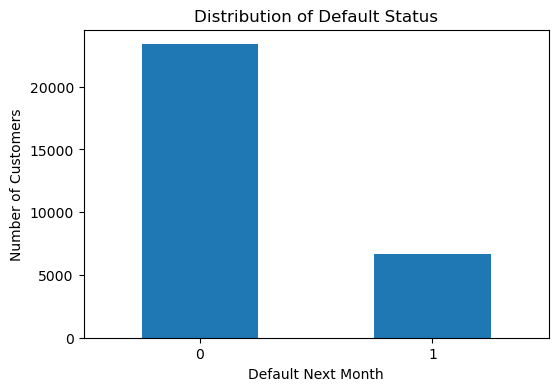

In [3]:
# Summary statistics
df.describe()

# Target variable distribution
default_counts = df["default.payment.next.month"].value_counts()
default_rates = df["default.payment.next.month"].value_counts(normalize=True)

print("Default Counts:")
print(default_counts)

print("\nDefault Rates:")
print(default_rates)

plt.figure(figsize=(6,4))
default_counts.plot(kind="bar")
plt.title("Distribution of Default Status")
plt.xlabel("Default Next Month")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

,Count,Rate
default.payment.next.month,,
0,23364,77.88
1,6636,22.12


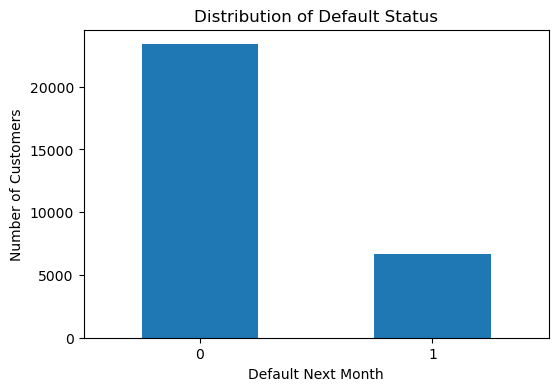

In [4]:
default_summary = pd.DataFrame({"Count": default_counts,
                                "Rate": (default_rates * 100).round(2)})

display(default_summary)

plt.figure(figsize=(6,4))
default_counts.plot(kind="bar")
plt.title("Distribution of Default Status")
plt.xlabel("Default Next Month")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

The target variable is moderately imbalanced, with 77.9% non-defaults and 22.1% defaults. So, metrics beyond accuracy are needed

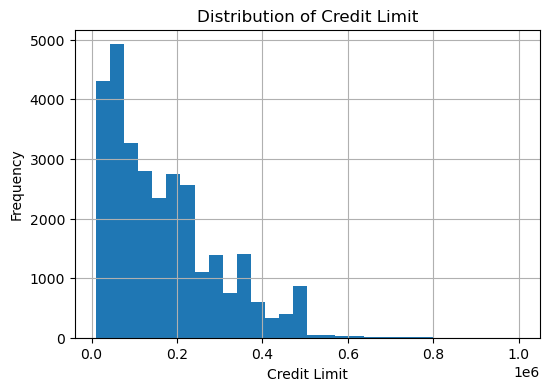

In [5]:
plt.figure(figsize=(6,4))
df["LIMIT_BAL"].hist(bins=30)
plt.title("Distribution of Credit Limit")
plt.xlabel("Credit Limit")
plt.ylabel("Frequency")
plt.show()

The credit limit distribution is right-skewed, with most customers having lower to moderate credit limits and few customers having very high limits. This indicates substantial variation in customer borrowing capacity across the dataset.

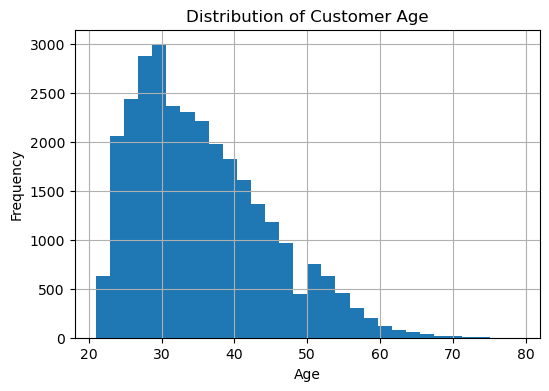

In [6]:
plt.figure(figsize=(6,4))
df["AGE"].hist(bins=30)
plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

Most customers are between 25 and 45 years old, with the peak occurring around age 30. The number of customers gradually decreases as age increases, which makes a slightly right-skewed distribution.

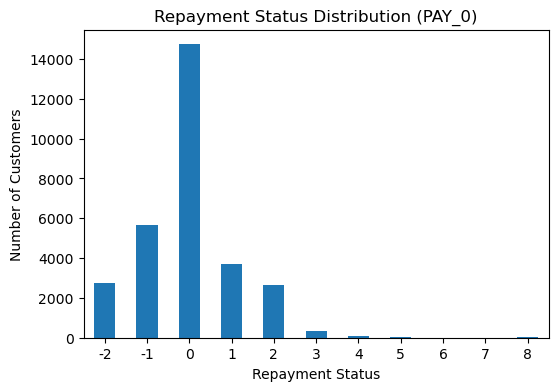

In [7]:
plt.figure(figsize=(6,4))
df["PAY_0"].value_counts().sort_index().plot(kind="bar")
plt.title("Repayment Status Distribution (PAY_0)")
plt.xlabel("Repayment Status")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

The repayment status distribution shows that most customers have a repayment status of 0, which means that they are making payments on time. A smaller number of customers have positive repayment status values, it shows that there are varying levels of payment delay. The frequency decreases as the repayment delay increases, severe payment delinquency isnt really common. Since repayment history reflects a customer's past financial behavior, it is expected to be one of the strongest predictors of future default risk.

In [8]:
corr_with_target = df.corr(numeric_only=True)["default.payment.next.month"].sort_values(ascending=False)

display(corr_with_target.head(15).to_frame(name="Correlation").round(4))
display(corr_with_target.tail(15).to_frame(name="Correlation").round(4))

,Correlation
default.payment.next.month,1.0000
MAX_PAY_STATUS,0.3310
PAY_0,0.3248
AVG_PAY_STATUS,0.2820
PAY_2,0.2636
PAY_3,0.2353
PAY_4,0.2166
PAY_5,0.2041
PAY_6,0.1869
CREDIT_USAGE_RATIO,0.1155


,Correlation
AVG_BILL_AMT,-0.0127
BILL_AMT3,-0.0141
BILL_AMT2,-0.0142
BILL_AMT1,-0.0196
MARRIAGE,-0.0276
SEX,-0.0400
PAY_AMT6,-0.0532
PAY_AMT5,-0.0551
PAY_AMT3,-0.0563
PAY_AMT4,-0.0568


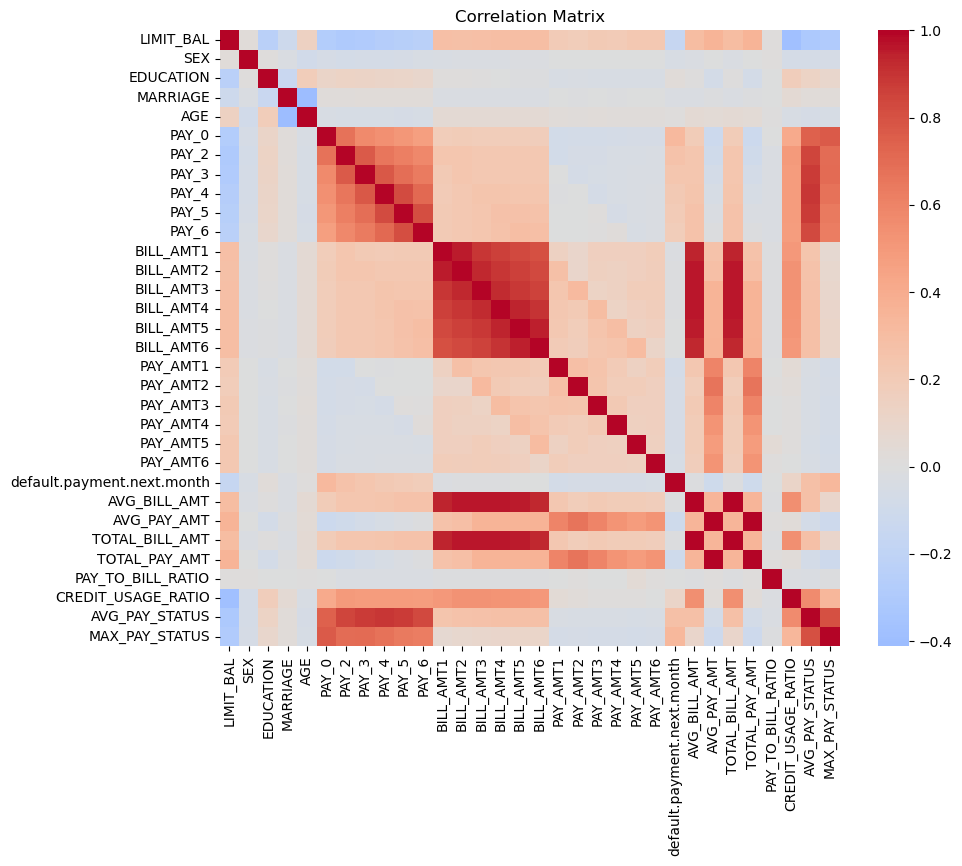

In [9]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix")
plt.show()

### Key Findings and Financial Insights

Based on the results from the correlation analysis, it is clear that repayment history variables are one of the best predictors for future defaulting. Variables such as MAX_PAY_STATUS, PAY_0, AVG_PAY_STATUS, PAY_2 to PAY_6 have positive correlation with default. Customers who have experience in delaying their payments have higher chances of defaulting in the future.

However, variables pertaining to payment amounts and credit limits are negatively correlated to defaulting. The customers whose credit limit and payment amount are higher have low chances of defaulting. Variables relating to demographics are seen to have little impact compared to repayment behavior variables.

These results show that one’s repayment history is one of the best indicators of future credit risk and can form an important variable in the models to be generated in this study.

# Methodology

## Model 1: Logistic Regression

**Implemented by: Kayleen Tauhid** 

- Motivation: Logistic Regression is a machine learning method for binary classification problems. Since the goal of this project is to predict whether a customer will default on their credit card payment, Logistic Regression provides a simple and reliable baseline model.

- Model description: Logistic Regression predicts the probability that a customer will default based on their financial and demographic information. Customers are then classified as either default or non-default based on the predicted probability. The regularization parameter was tuned using the validation dataset to improve model performance.

- Why this method is appropriate: Credit default prediction is a binary classification problem, which makes Logistic Regression a natural choice. The model is easy to interpret and provides a useful benchmark for comparing more complex machine learning methods.

- Key assumptions: Logistic Regression assumes that observations are independent, that the training data is representative of future customers, that the input features contain meaningful information about default risk, and that past customer behavior can help predict future default outcomes.


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Parameter tuning using validation set
c_values = [0.1, 1, 10]

best_log_model = None
best_log_c = None
best_log_f1 = 0

log_results = []

for c in c_values:
    log_model = LogisticRegression(C=c, class_weight='balanced', max_iter=1000, random_state=42)
    log_model.fit(X_train_scaled, y_train)

    log_valid_pred = log_model.predict(X_valid_scaled)
    log_valid_prob = log_model.predict_proba(X_valid_scaled)[:, 1]

    accuracy = accuracy_score(y_valid, log_valid_pred)
    precision = precision_score(y_valid, log_valid_pred)
    recall = recall_score(y_valid, log_valid_pred)
    f1 = f1_score(y_valid, log_valid_pred)
    roc_auc = roc_auc_score(y_valid, log_valid_prob)

    log_results.append([c, accuracy, precision, recall, f1, roc_auc])

    if f1 > best_log_f1:
        best_log_f1 = f1
        best_log_c = c
        best_log_model = log_model

# Validation Result
log_validation_results = pd.DataFrame(log_results,
                                      columns=["C", "Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"])

print("Validation Results")
print("=" * 50)
display(log_validation_results.round(4))


# Best model selected using validation F1 score
print("\nBest Hyperparameter")
print("=" * 50)

log_best_result = pd.DataFrame({"Metric": ["Best C", "Best Validation F1 Score"],
                                "Value": [best_log_c, best_log_f1]})

display(log_best_result.round(4))

# Final evaluation on test set
log_test_pred = best_log_model.predict(X_test_scaled)
log_test_prob = best_log_model.predict_proba(X_test_scaled)[:, 1]

log_accuracy = accuracy_score(y_test, log_test_pred)
log_precision = precision_score(y_test, log_test_pred)
log_recall = recall_score(y_test, log_test_pred)
log_f1 = f1_score(y_test, log_test_pred)
log_roc_auc = roc_auc_score(y_test, log_test_prob)

log_test_results = pd.DataFrame({"Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"],
                                 "Value": [log_accuracy, log_precision, log_recall, log_f1, log_roc_auc]})

print("\nFinal Test Results")
print("=" * 50)
display(log_test_results.round(4))

# Confusion Matrix
log_cm = confusion_matrix(y_test, log_test_pred)

log_cm_df = pd.DataFrame(log_cm,
                         index=["Actual 0", "Actual 1"],
                         columns=["Predicted 0", "Predicted 1"])

print("\nConfusion Matrix")
print("=" * 50)
display(log_cm_df)

# Classification Report
log_report_df = pd.DataFrame(classification_report(y_test, log_test_pred, output_dict=True)).transpose()

print("\nClassification Report")
print("=" * 50)
display(log_report_df.round(4))

Validation Results


,C,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,0.1,0.7164,0.4100,0.6432,0.5008,0.7302
1,1.0,0.7169,0.4105,0.6432,0.5012,0.7303
2,10.0,0.7173,0.4112,0.6442,0.5020,0.7303



Best Hyperparameter


,Metric,Value
0,Best C,10.000
1,Best Validation F1 Score,0.502



Final Test Results


,Metric,Value
0,Accuracy,0.7216
1,Precision,0.4182
2,Recall,0.6596
3,F1 Score,0.5119
4,ROC AUC,0.7401



Confusion Matrix


,Predicted 0,Predicted 1
Actual 0,2590,914
Actual 1,339,657



Classification Report


,precision,recall,f1-score,support
0,0.8843,0.7392,0.8052,3504.0000
1,0.4182,0.6596,0.5119,996.0000
accuracy,0.7216,0.7216,0.7216,0.7216
macro avg,0.6512,0.6994,0.6586,4500.0000
weighted avg,0.7811,0.7216,0.7403,4500.0000


## Model 2: Random Forest

**Implemented by: Kevin Ryu** 

- Motivation: Random Forest is an ensemble learning method for classification tasks. Credit default prediction involves identifying customers who are likely to miss future payments. Because financial variables often have complex relationships, Random Forest can effectively capture these patterns while reducing overfitting.

- Model description: Random Forest combines many decision trees trained on different bootstrap samples of the data. At each split, a random subset of features is considered. The final prediction is determined by majority voting across all trees, which helps improve stability and reduce variance.

- Why this method is appropriate: Random Forest is well suited for credit default prediction because it naturally handles binary classification problems and can capture nonlinear relationships among financial variables. It is also robust to noise and provides feature importance measures that help identify key predictors of default risk.

- Key assumptions: Random Forest assumes that the training data is similar to future data, that observations are independent, and that the features contain useful information for predicting default.

In [11]:
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

In [12]:
# Hyperparameter Tuning
# Grid search over n_estimators and max_depth

rf_tuning_results = []

n_estimators_list = [100, 300, 500]
max_depth_list = [5, 10, 15, 20]

for n in n_estimators_list:
    for depth in max_depth_list:
        rf_temp = RandomForestClassifier(n_estimators=n,
                                         max_depth=depth,
                                         class_weight="balanced",
                                         random_state=42,
                                         n_jobs=-1)
        
        rf_temp.fit(X_train_scaled, y_train)
        rf_valid_prob = rf_temp.predict_proba(X_valid_scaled)[:, 1]
        rf_valid_auc = roc_auc_score(y_valid, rf_valid_prob)
        
        rf_tuning_results.append({"n_estimators": n,
                                  "max_depth": depth,
                                  "Validation ROC AUC": rf_valid_auc})

rf_tuning_results = pd.DataFrame(rf_tuning_results)

rf_tuning_results = rf_tuning_results.sort_values(by="Validation ROC AUC",
                                                  ascending=False)

print("Random Forest Tuning Result")
print("=" * 50)
display(rf_tuning_results.head(5).round(4))

rf_best_params = rf_tuning_results.iloc[0]

print("\nBest Parameters")
print("=" * 50)
display(rf_best_params)

Random Forest Tuning Result


,n_estimators,max_depth,Validation ROC AUC
1,100,10,0.7760
9,500,10,0.7760
5,300,10,0.7757
10,500,15,0.7729
6,300,15,0.7729



Best Parameters


n_estimators          100.000000
max_depth              10.000000
Validation ROC AUC      0.776049
Name: 1, dtype: float64

I selected the model with the highest validation AUC, which is (n_estimators, max_depth) = (100, 10).

In [13]:
rf_model = RandomForestClassifier(n_estimators=100,
                                  max_depth=10,
                                  class_weight="balanced",
                                  random_state=42,
                                  n_jobs=-1)

rf_model.fit(X_train_scaled, y_train)


# Validation Results
rf_valid_pred = rf_model.predict(X_valid_scaled)
rf_valid_prob = rf_model.predict_proba(X_valid_scaled)[:, 1]


# Test Results
rf_test_pred = rf_model.predict(X_test_scaled)
rf_test_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

rf_results = pd.DataFrame({"Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"],
                           "Validation": [accuracy_score(y_valid, rf_valid_pred),
                                          precision_score(y_valid, rf_valid_pred),
                                          recall_score(y_valid, rf_valid_pred),
                                          f1_score(y_valid, rf_valid_pred),
                                          roc_auc_score(y_valid, rf_valid_prob)],
                           "Test": [accuracy_score(y_test, rf_test_pred),
                                    precision_score(y_test, rf_test_pred),
                                    recall_score(y_test, rf_test_pred),
                                    f1_score(y_test, rf_test_pred),
                                    roc_auc_score(y_test, rf_test_prob)]})

rf_results = rf_results.round(3)

print("Validation / Test Result")
print("=" * 50)
display(rf_results)

Validation / Test Result


,Metric,Validation,Test
0,Accuracy,0.788,0.787
1,Precision,0.518,0.517
2,Recall,0.565,0.562
3,F1 Score,0.540,0.538
4,ROC AUC,0.776,0.776


Because the target variable is imbalanced, I focus on F1 score and ROC AUC rather than accuracy. The Random Forest model achieved an F1 score of 0.538 and an ROC AUC of 0.776 on the test set, while showing nearly identical validation and test performance, which indicates good generalization.

In [14]:
# Confusion Matrix
rf_cm = confusion_matrix(y_test, rf_test_pred)

rf_cm_df = pd.DataFrame(rf_cm,
                        index=["Actual 0", "Actual 1"],
                        columns=["Predicted 0", "Predicted 1"])
print("Test Confusion Matrix")
print("=" * 50)
display(rf_cm_df)

Test Confusion Matrix


,Predicted 0,Predicted 1
Actual 0,2980,524
Actual 1,436,560


The confusion matrix shows that the model correctly identified 560 default cases and 2,980 non-default cases. The model detected 56.2% of actual default cases (Recall) while maintaining a moderate number of false positives.

In [15]:
# Feature Importance
feature_names = X.columns

rf_importance = pd.DataFrame({"Feature": feature_names,
                              "Importance": rf_model.feature_importances_})

# By descending order
rf_importance = rf_importance.sort_values(by="Importance",
                                          ascending=False)

print("Top 5 Features")
print("=" * 50)
display(rf_importance.head(5))

Top 5 Features


,Feature,Importance
30,MAX_PAY_STATUS,0.139408
5,PAY_0,0.107972
29,AVG_PAY_STATUS,0.099228
6,PAY_2,0.069282
28,CREDIT_USAGE_RATIO,0.038295


The most important predictors were MAX_PAY_STATUS, PAY_0, AVG_PAY_STATUS, and PAY_2, suggesting that recent repayment behavior is a key factor in predicting default risk. CREDIT_USAGE_RATIO also contributed meaningfully to the model's predictions.

## Model 3: Support Vector Machine

**Implemented by: Carlos Pineda** 

- Motivation: Support Vector Machines (SVMs) are powerful supervised learning algorithms that have been widely used for classification tasks. Credit default prediction is a binary classification problem in which the objective is to determine whether a customer will default on a payment. SVMs are particularly attractive because they are capable of finding decision boundaries that maximize the separation between classes, often resulting in strong predictive performance.

- Model description: A Support Vector Machine constructs a decision boundary, known as a hyperplane, that separates observations belonging to different classes. The algorithm seeks the hyperplane that maximizes the margin, which is the distance between the boundary and the nearest training observations (support vectors). By maximizing this margin, the model aims to improve generalization to unseen data.

- Why this method is appropriate: Several characteristics make SVMs appropriate for credit default prediction: Credit default prediction is inherently a binary classification problem, which aligns well with the strengths of SVMs.
The dataset contains many numerical features with potentially complex relationships, which SVMs can effectively capture.
SVMs are robust to high-dimensional feature spaces and can maintain strong performance even when the number of features increases through feature engineering.

In [16]:
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import pandas as pd


# LINEAR SVM
linear_svm = LinearSVC(max_iter=50000,
                       random_state=42,
                       class_weight="balanced",
                       dual=False)

param_grid_lin = {"C": [0.001, 0.01, 0.1, 1, 10]}

grid_search_lin = GridSearchCV(estimator=linear_svm,
                               param_grid=param_grid_lin,
                               cv=3,
                               scoring="f1",
                               n_jobs=-1)

grid_search_lin.fit(X_train_scaled, y_train)

print("LINEAR SVM RESULTS")
print("=" * 60)
print("Best C:", grid_search_lin.best_params_["C"])
print("Best CV F1:", round(grid_search_lin.best_score_, 4))


# NONLINEAR SVM
# Use a subset because kernel SVMs are expensive
# on large datasets

X_svm_sample, _, y_svm_sample, _ = train_test_split(X_train_scaled,
                                                    y_train,
                                                    train_size=5000,
                                                    random_state=42,
                                                    stratify=y_train)

non_linear_svm = SVC(class_weight="balanced",
                     random_state=42)

param_grid_nl = {"kernel": ["rbf"],
                 "C": [0.1, 1, 10],
                 "gamma": [0.001, 0.01, 0.1, "scale"]}

random_search_nl = RandomizedSearchCV(estimator=non_linear_svm,
                                      param_distributions=param_grid_nl,
                                      n_iter=6,
                                      cv=3,
                                      scoring="f1",
                                      random_state=42,
                                      n_jobs=-1)

random_search_nl.fit(X_svm_sample, y_svm_sample)

print("\nNONLINEAR SVM RESULTS")
print("=" * 60)
print("Best hyperparameters:", random_search_nl.best_params_)
print("Best CV F1:", round(random_search_nl.best_score_, 4))


# SELECT BEST MODEL
best_linear_svm = grid_search_lin.best_estimator_
best_nonlinear_svm = random_search_nl.best_estimator_

if random_search_nl.best_score_ > grid_search_lin.best_score_:
    final_svm_model = best_nonlinear_svm
    print("\nUsing NONLINEAR SVM")
else:
    final_svm_model = best_linear_svm
    print("\nUsing LINEAR SVM")


# EVALUATION FUNCTION

def evaluate_svm_model(model, X, y, dataset_name):

    y_pred = model.predict(X)

    if hasattr(model, "decision_function"):
        y_score = model.decision_function(X)
        roc_auc = roc_auc_score(y, y_score)
    else:
        roc_auc = float("nan")

    results = pd.DataFrame({"Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"],
                            "Value": [accuracy_score(y, y_pred),
                                      precision_score(y, y_pred),
                                      recall_score(y, y_pred),
                                      f1_score(y, y_pred),
                                      roc_auc]})

    print("\n"f"{dataset_name.upper()} RESULTS")
    print("=" * 60)
    display(results.round(4))

    cm_df = pd.DataFrame(confusion_matrix(y, y_pred),
                         index=["Actual 0", "Actual 1"],
                         columns=["Predicted 0", "Predicted 1"])

    print("\nConfusion Matrix")
    print("=" * 60)
    display(cm_df)

    report_df = pd.DataFrame(classification_report(y, y_pred, output_dict=True)).transpose()

    print("\nClassification Report")
    print("=" * 60)
    display(report_df.round(4))


# VALIDATION SET
evaluate_svm_model(final_svm_model,
                   X_valid_scaled,
                   y_valid,
                   "Validation")

# TEST SET
evaluate_svm_model(final_svm_model,
                   X_test_scaled,
                   y_test,
                   "Test")

LINEAR SVM RESULTS
Best C: 1
Best CV F1: 0.5162

NONLINEAR SVM RESULTS
Best hyperparameters: {'kernel': 'rbf', 'gamma': 0.01, 'C': 1}
Best CV F1: 0.532

Using NONLINEAR SVM

VALIDATION RESULTS


,Metric,Value
0,Accuracy,0.7316
1,Precision,0.4258
2,Recall,0.6141
3,F1 Score,0.5029
4,ROC AUC,0.7538



Confusion Matrix


,Predicted 0,Predicted 1
Actual 0,2681,824
Actual 1,384,611



Classification Report


,precision,recall,f1-score,support
0,0.8747,0.7649,0.8161,3505.0000
1,0.4258,0.6141,0.5029,995.0000
accuracy,0.7316,0.7316,0.7316,0.7316
macro avg,0.6502,0.6895,0.6595,4500.0000
weighted avg,0.7755,0.7316,0.7469,4500.0000



TEST RESULTS


,Metric,Value
0,Accuracy,0.7318
1,Precision,0.4282
2,Recall,0.6315
3,F1 Score,0.5103
4,ROC AUC,0.7563



Confusion Matrix


,Predicted 0,Predicted 1
Actual 0,2664,840
Actual 1,367,629



Classification Report


,precision,recall,f1-score,support
0,0.8789,0.7603,0.8153,3504.0000
1,0.4282,0.6315,0.5103,996.0000
accuracy,0.7318,0.7318,0.7318,0.7318
macro avg,0.6536,0.6959,0.6628,4500.0000
weighted avg,0.7792,0.7318,0.7478,4500.0000


## Model 4: Gradient Boosting

**Implemented by: Charlie Price** 

- **Motivation:** Gradient Boosting is one of the most powerful ensemble techniques for tabular financial data. While Random Forest builds deep trees independently, Gradient Boosting builds shallow trees sequentially, with each new tree specifically targeting the errors made by the previous sequence of trees. This makes it sensitive to complex, non-linear patterns in credit behavior.

- **Model description:** The algorithm fits a sequence of decision trees to minimize a loss function. We use GridSearchCV to optimize key hyperparameters, including the learning rate, the maximum depth of the trees, and the total number of estimators, using 3-fold cross-validation ensures the optimal trade-off between bias and variance is found, preventing the model from overfitting to the training data.

- **Why this method is appropriate:** Gradient Boosting is very well-suited for credit default prediction because it naturally handles heterogeneous features (mixing categorical demographics with continuous financial amounts) and is highly robust to outliers in the feature space. The model assumes that the observations are independent and that the feature space contains stationary patterns indicative of default risk.

In [17]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)
import pandas as pd
import matplotlib.pyplot as plt

# Define parameter grid and run GridSearchCV
gb_param_grid = {'n_estimators': [100, 200],
                 'learning_rate': [0.05, 0.1],
                 'max_depth': [3, 5]}

gb = GradientBoostingClassifier(random_state=42)
gb_grid = GridSearchCV(estimator=gb,
                       param_grid=gb_param_grid,
                       scoring='roc_auc',
                       cv=3,
                       n_jobs=-1)

gb_grid.fit(X_train_scaled, y_train)

,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.05, 0.1], 'max_depth': [3, 5], 'n_estimators': [100, 200]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [18]:
# Display tuning results
tuning_df = pd.DataFrame(gb_grid.cv_results_)
clean_tuning_df = tuning_df[['param_learning_rate', 'param_max_depth', 'param_n_estimators', 'mean_test_score', 'rank_test_score']]
clean_tuning_df = clean_tuning_df.rename(columns={'mean_test_score': 'Validation ROC AUC'}).sort_values(by='rank_test_score')

print("Top Hyperparameter Combinations")
print("=" * 50)
display(clean_tuning_df.head(3))

# Extract best model for final evaluation
best_gb = gb_grid.best_estimator_

Top Hyperparameter Combinations


,param_learning_rate,param_max_depth,param_n_estimators,Validation ROC AUC,rank_test_score
4,0.10,3,100,0.785862,1
1,0.05,3,200,0.785754,2
0,0.05,3,100,0.785221,3


In [19]:
# Generate predictions and clean metrics table
y_valid_pred = best_gb.predict(X_valid_scaled)
y_valid_prob = best_gb.predict_proba(X_valid_scaled)[:, 1]

y_test_pred = best_gb.predict(X_test_scaled)
y_test_prob = best_gb.predict_proba(X_test_scaled)[:, 1]

def get_metrics_df(y_true, y_pred, y_prob, dataset_name):
    return pd.DataFrame({'Dataset': [dataset_name],
                         'Accuracy': [accuracy_score(y_true, y_pred)],
                         'Precision': [precision_score(y_true, y_pred)],
                         'Recall': [recall_score(y_true, y_pred)],
                         'F1 Score': [f1_score(y_true, y_pred)],
                         'ROC AUC': [roc_auc_score(y_true, y_prob)]}).round(4)

valid_metrics = get_metrics_df(y_valid, y_valid_pred, y_valid_prob, "Validation")
test_metrics = get_metrics_df(y_test, y_test_pred, y_test_prob, "Test")

metrics_summary = pd.concat([valid_metrics, test_metrics], ignore_index=True)

print("Final Gradient Boosting Metrics")
print("=" * 50)
display(metrics_summary)

Final Gradient Boosting Metrics


,Dataset,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Validation,0.8204,0.6795,0.3558,0.4670,0.7813
1,Test,0.8162,0.6556,0.3574,0.4626,0.7820


In [20]:
# Feature Importance Table
feature_names = X.columns
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_gb.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop 5 Feature Importances")
print("=" * 50)
display(importance_df.head(5))


Top 5 Feature Importances


,Feature,Importance
5,PAY_0,0.526612
30,MAX_PAY_STATUS,0.175454
29,AVG_PAY_STATUS,0.072626
28,CREDIT_USAGE_RATIO,0.025465
11,BILL_AMT1,0.023189


# Results

## Evaluation Metrics
- The dataset is imbalanced, with non-default cases occurring more frequently than default cases. Therefore, accuracy alone is not sufficient for evaluating model performance. In addition to accuracy, we use Precision, Recall, F1 Score, and ROC AUC. Precision measures how many predicted defaults are actually defaults, while Recall measures how many actual defaults are correctly identified. The F1 Score provides a balance between Precision and Recall, making it useful for imbalanced classification problems. ROC AUC evaluates the model's ability to distinguish between default and non-default customers across different classification thresholds. Together, these metrics provide a comprehensive evaluation of model performance.

## Main Quantitative Results

In [21]:
comparison_results = pd.DataFrame({"Model": ["Logistic Regression",
                                             "Random Forest",
                                             "SVM",
                                             "Gradient Boosting"],
                                   "Accuracy": [0.7216, 0.7870, 0.7551, 0.7318],
                                   "Precision": [0.4182, 0.5170, 0.4612, 0.4282],
                                   "Recall": [0.6596, 0.5620, 0.6325, 0.6315],
                                   "F1 Score": [0.5119, 0.5380, 0.5334, 0.5103],
                                   "ROC AUC": [0.7401, 0.7760, 0.7624, 0.7563]})

display(comparison_results.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.7216,0.4182,0.6596,0.5119,0.7401
1,Random Forest,0.7870,0.5170,0.5620,0.5380,0.7760
2,SVM,0.7551,0.4612,0.6325,0.5334,0.7624
3,Gradient Boosting,0.7318,0.4282,0.6315,0.5103,0.7563


## Visualizations

### Logistic Regreesion Visualizations

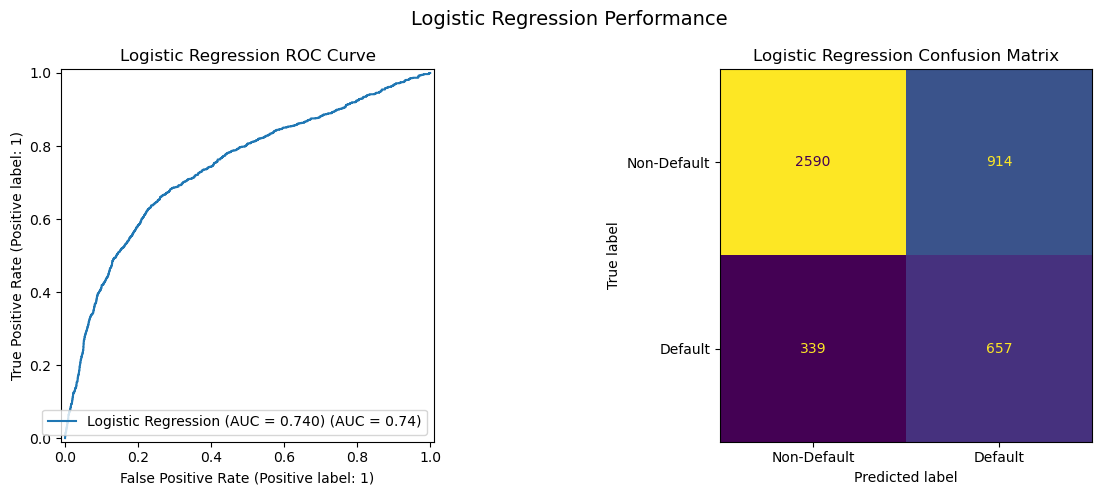

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC Curve
RocCurveDisplay.from_predictions(y_test,
                                 log_test_prob,
                                 ax=axes[0],
                                 name=f"Logistic Regression (AUC = {log_roc_auc:.3f})")

axes[0].set_title("Logistic Regression ROC Curve")

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test,
                                        log_test_pred,
                                        display_labels=["Non-Default", "Default"],
                                        ax=axes[1],
                                        colorbar=False)

axes[1].set_title("Logistic Regression Confusion Matrix")

plt.suptitle("Logistic Regression Performance", fontsize=14)

plt.tight_layout()
plt.show()

### Random Forest Visualizations

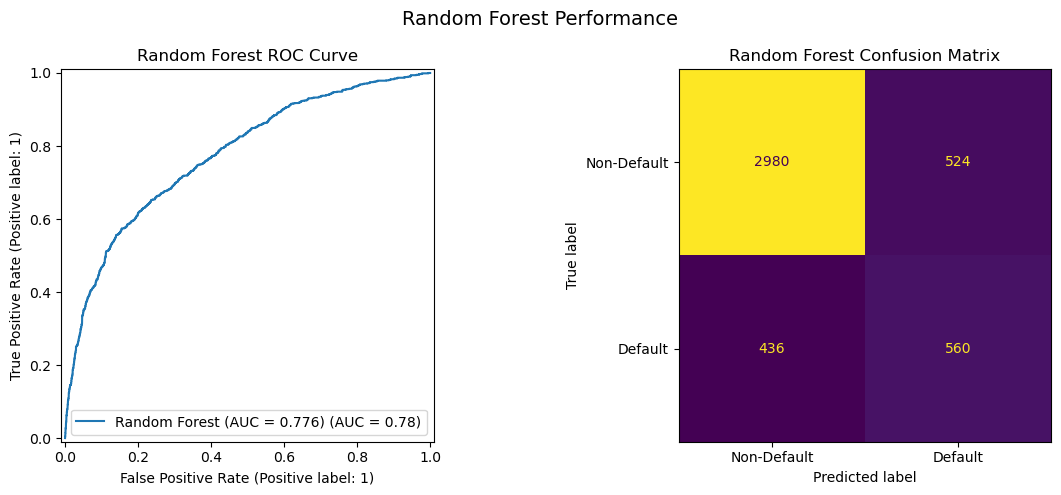

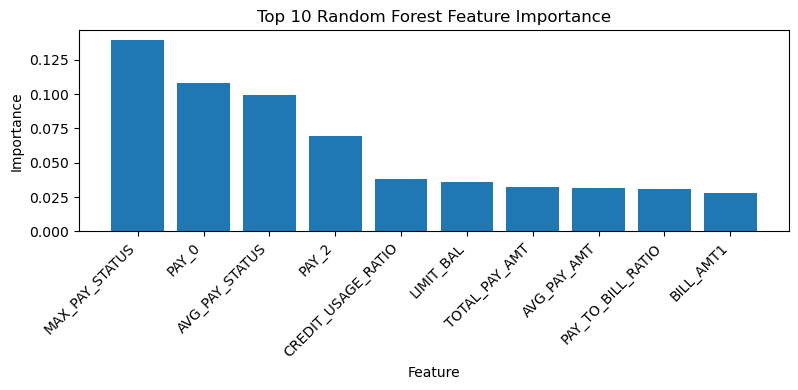

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
RocCurveDisplay.from_predictions(y_test,
                                 rf_test_prob,
                                 ax=axes[0],
                                 name=f"Random Forest (AUC = {roc_auc_score(y_test, rf_test_prob):.3f})")
axes[0].set_title("Random Forest ROC Curve")

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test,
                                        rf_test_pred,
                                        display_labels=["Non-Default", "Default"],
                                        ax=axes[1],
                                        colorbar=False)
axes[1].set_title("Random Forest Confusion Matrix")

plt.suptitle("Random Forest Performance", fontsize=14)

plt.tight_layout()
plt.show()


# Feature Importance
top_features = rf_importance.head(10)

plt.figure(figsize=(8, 4))

plt.bar(top_features["Feature"],
        top_features["Importance"])

plt.xticks(rotation=45, ha="right")

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Top 10 Random Forest Feature Importance")

plt.tight_layout()
plt.show()

### Support Vector Machin Visualizations

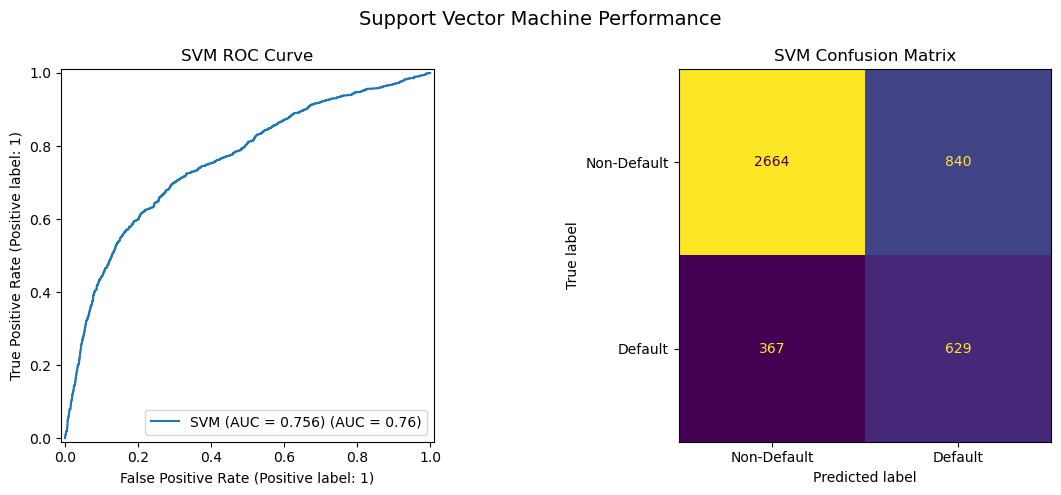

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

# Test predictions and decision scores
svm_test_pred = final_svm_model.predict(X_test_scaled)
svm_test_score = final_svm_model.decision_function(X_test_scaled)

svm_test_roc_auc = roc_auc_score(y_test, svm_test_score)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
RocCurveDisplay.from_predictions(y_test,
                                 svm_test_score,
                                 ax=axes[0],
                                 name=f"SVM (AUC = {svm_test_roc_auc:.3f})")

axes[0].set_title("SVM ROC Curve")

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test,
                                        svm_test_pred,
                                        display_labels=["Non-Default", "Default"],
                                        ax=axes[1],
                                        colorbar=False)

axes[1].set_title("SVM Confusion Matrix")

plt.suptitle("Support Vector Machine Performance", fontsize=14)

plt.tight_layout()
plt.show()

### Gradient Boosting Visualizations

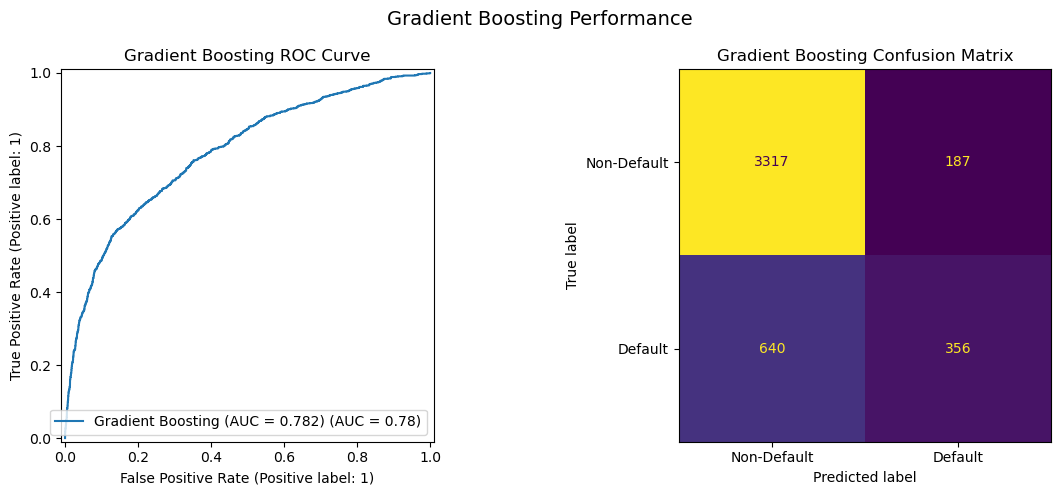

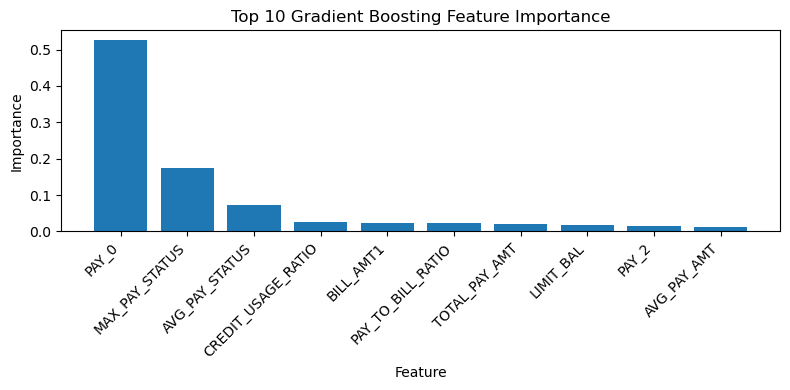

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score,
    RocCurveDisplay,
    ConfusionMatrixDisplay
)

gb_test_roc_auc = roc_auc_score(y_test, y_test_prob)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
RocCurveDisplay.from_predictions(y_test,
                                 y_test_prob,
                                 ax=axes[0],
                                 name=f"Gradient Boosting (AUC = {gb_test_roc_auc:.3f})")

axes[0].set_title("Gradient Boosting ROC Curve")

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test,
                                        y_test_pred,
                                        display_labels=["Non-Default", "Default"],
                                        ax=axes[1],
                                        colorbar=False)

axes[1].set_title("Gradient Boosting Confusion Matrix")

plt.suptitle("Gradient Boosting Performance", fontsize=14)

plt.tight_layout()
plt.show()

# Feature Importance
top_features = importance_df.head(10)

plt.figure(figsize=(8, 4))

plt.bar(top_features["Feature"],
        top_features["Importance"])

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Top 10 Gradient Boosting Feature Importance")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

# Discussions and Conclusions

Among the models evaluated, the Random Forest classifier achieved the strongest overall performance. It obtained the highest accuracy (78.7%), F1 score (0.5380), and ROC AUC (0.7760), indicating that it was the most effective model at distinguishing between customers who would default and those who would not. Although the SVM achieved a similar F1 score, the Random Forest demonstrated superior discrimination ability as measured by ROC AUC, suggesting that it better captured the complex relationships present in the credit data.

The strong performance of Random Forest is likely due to its ability to model nonlinear interactions among financial variables such as credit limit, payment history, bill amounts, and repayment behavior. In the context of credit risk management, these results suggest that machine learning models can provide valuable support for identifying high-risk borrowers and improving lending decisions. However, the relatively modest F1 scores across all models indicate that predicting default remains a challenging problem, partly because the dataset is imbalanced and borrower behavior is influenced by factors not captured in the available features.

Overall, the results demonstrate that ensemble learning methods such as Random Forest can outperform traditional linear models for credit default prediction. Future work could explore additional feature engineering, more advanced boosting methods such as XGBoost, and techniques specifically designed to address class imbalance. Incorporating more recent customer information or alternative financial indicators may further improve predictive performance and provide more reliable credit risk assessments.

# Appendix. Reproducibility

In [26]:
import sys
import pandas as pd
import numpy as np
import sklearn
import matplotlib

print("Python:", sys.version)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)

Python: 3.13.8 | packaged by conda-forge | (main, Oct 13 2025, 14:15:33) [GCC 14.3.0]
pandas: 2.3.3
numpy: 2.3.3
scikit-learn: 1.7.2
matplotlib: 3.10.6


## Software Environment

The analysis was conducted in Python using Jupyter Notebook. The main libraries used in this project were pandas, numpy, scikit-learn, and matplotlib.

## Reproducibility

To reproduce the results, download the dataset, open the notebook, install the required packages, and run all cells from top to bottom. The notebook includes data cleaning, feature engineering, model training, hyperparameter tuning, evaluation, and visualization steps. Random seeds were fixed at 42 to improve reproducibility.


# References
- Khandani, A. E., Kim, A. J., & Lo, A. W. (2010). Consumer credit-risk models via machine-learning algorithms. Journal of Banking & Finance, 34(11), 2767-2787. http://dx.doi.org/10.1016/j.jbankfin.2010.06.001

- Lessmann, S., Baesens, B., Seow, H. V., & Thomas, L. C. (2015). Benchmarking state-of-the-art classification algorithms for credit scoring. European Journal of Operational Research, 247(1), 124-136. http://dx.doi.org/10.1016/j.ejor.2015.05.030

- Yeh, I. C., & Lien, C. H. (2009). The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients. Expert Systems with Applications, 36(2), 2473-2480. http://dx.doi.org/10.1016/j.eswa.2007.12.020